# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ - check Kyle's Hamiltonian

Created: 30-07-2026

Objectives:
Kyle proposed the following Hamiltoniain for a fermionic decorated domain wall state: $$H = -\sum_k -i \gamma_{k-1} Z_k \gamma_k + Y_k (-1)^n_k Y_{k+1}$$
Want to check that that this state is equivalent to our previous states.

# Imports

In [1]:
import numpy as np
import pandas as pd

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul
from itertools import product
from collections import Counter

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [8]:
from time import time

In [9]:
from humanize import naturalsize

In [10]:
import pickle

In [11]:
DATA_DIR = r"../../data/z2_f_x_z2_t_triv_to_nontriv_n1_8_site_ed"

# Make Kyle's Hamiltonian

In [12]:
L=8

In [150]:
spin_basis = spin_basis_1d(L, pauli=-1)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [151]:
majorana_1 = [('+', 1) ,('-', 1)]
majorana_2 = [('+', 1),  ('-', -1)]

In [152]:
spin_terms=[
    [f'z|{op_l}{op_r}', [[-1*s_l*s_r, i, (i-1)%L, i] for i in range(L)]]
    for op_l, s_l in majorana_2
    for op_r, s_r in majorana_1
]

In [153]:
fermion_terms = [
    [f'yy|I', [[-1, i, (i+1)%L, i] for i in range(L)]],
    [f'yy|n', [[2, i, (i+1)%L, i] for i in range(L)]]
]

In [154]:
all_terms = spin_terms + fermion_terms

In [155]:
h = hamiltonian(
    all_terms,
    [],
    basis=basis,
    dtype=np.complex128,
    check_symm=False,
    check_herm=True
)

Hermiticity check passed!


/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_4353/1596409324.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(


In [156]:
e, psi = h.eigsh(k=1, which='SA')

In [157]:
e

array([-16.])

In [158]:
comparison_psi = np.load(rf'{DATA_DIR}/100.npz')['psi'][:, 0]

In [159]:
psi.shape

(65536, 1)

In [160]:
comparison_psi.shape

(65536,)

In [161]:
np.abs(np.sum(psi[:, 0].conj() * comparison_psi))

np.float64(0.9999999999999969)

So the states are the same.

# Definitions

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [85]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [86]:
# Fermion parity on fermion sites
qu_FP = qtn.Tensor(np_Z, inds=['k', 'b'])

In [87]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [88]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [89]:
def get_multisite_qu_FP(sites):
    # Assuming fermion sites are on odd sites
    arrays = [
        (np_Z if (i%2) else np_I)
        for i in sites
    ]

    np_multisite_FP = multikron(arrays)

    out = qtn.Tensor(
        np_multisite_FP,
        inds=['k', 'b'],
        tags='multisite_FP',
    )

    return out

## Defect operators

In [90]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [91]:
def get_rho_tilde(mps_decomp, domains_dict):
    # rho_tilde is a reduced density matrix with the bra part complex conjugated
    A = mps_decomp

    # Left side
    A_l = A.tensors[next(iter(A.ind_map['vLV']))]
    k_left_ind = min(domains_dict['symmetry_sites'])
    dummy_left_index = f'vH{k_left_ind}'
    
    tn_l = (
        A_l
        &
        A_l.conj().reindex({
            f'k{k_left_ind}': f'b{k_left_ind}',
            dummy_left_index: 'dl',
        })
    )
    tn_l = tn_l.contract()

    left_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=[f'k{k_left_ind}', dummy_left_index],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    # Right side
    A_r = A.tensors[next(iter(A.ind_map['vRV']))]
    k_right_ind = max(domains_dict['symmetry_sites'])
    dummy_right_index = f'vH{k_right_ind-1}'

    tn_r = (
        A_r
        &
        A_r.conj().reindex({
            f'k{k_right_ind}': f'b{k_right_ind}',
            dummy_right_index: 'dr',
        })
    )
    tn_r = tn_r.contract()

    right_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=[f'k{k_right_ind}', dummy_right_index],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    ket_tensors = [
        *left_decomp.tensors[:-1],
        *[t for t in mps_decomp.tensors[1:-1]],
        *right_decomp.tensors[:-1]
    ]

    bra_tensors = [
        left_decomp.tensors[-1].conj().reindex({'dl': dummy_left_index}),
        *[
            t.reindex({f'k{i}': f'b{i}'})
            for t, i in zip(mps_decomp.tensors[1:-1], domains_dict['symmetry_sites'][1:-1])
        ],
        right_decomp.tensors[-1].conj().reindex({'dr': dummy_right_index})
    ]

    ket_tn = qtn.TensorNetwork(ket_tensors)
    bra_tn = qtn.TensorNetwork(bra_tensors).mangle_inner_()

    rho_tilde = ket_tn & bra_tn

    return rho_tilde

In [92]:
def get_edm_from_rho_tilde(rho_tilde, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )
    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        rho_tilde.reindex({f'b{i}': f'k{i}' for i in central_sites})
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [93]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    rho_tilde = get_rho_tilde(mps_decomp, domains_dict)

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

In [94]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [95]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [96]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

# Check symmetries

## $Z$ symmetries

In [97]:
np_Z = np.array([
    [1,0],
    [0,-1]
])
qu_Z = qtn.Tensor(np_Z, inds=['k', 'b'])

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [100]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(5, 10)),
    'left_defect_sites': [5,],
    'right_defect_sites': [9,]
}

all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

left_non_symmetry_sites = list(range(min(domains_dict['symmetry_sites'])))
right_non_symmetry_sites = list(range(
    max(domains_dict['symmetry_sites']),
    domains_dict['num_system_sites']
))

In [101]:
qt_psi = qtn.Tensor(
    psi[::-1].reshape((2,)*(2*L)),
    inds=inds
)

In [102]:
sym_gates = [
    qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
    for i in range(0, 2*L, 2)
]

In [103]:
sym_qt_psi = qtn.TensorNetwork(
    [qt_psi.reindex({f'k{i}': f'b{i}' for i in range(0, 2*L, 2)}),]
    + sym_gates
)

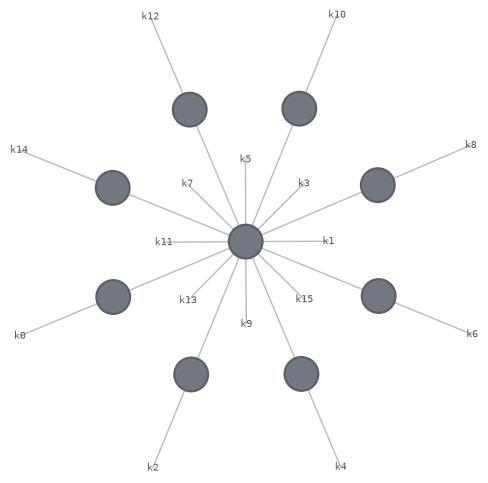

In [104]:
sym_qt_psi.draw()

In [105]:
sym_qt_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=16)

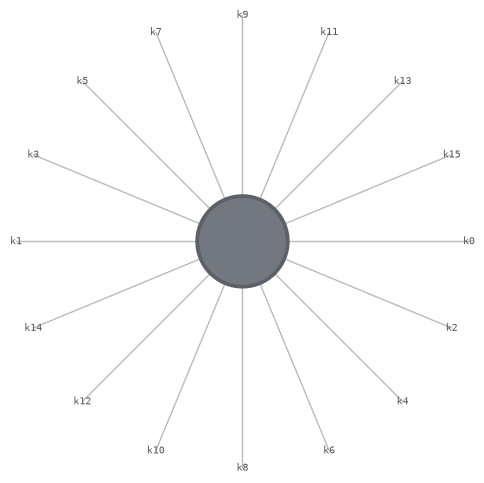

In [106]:
sym_qt_psi.draw()

In [107]:
(sym_qt_psi & sym_qt_psi.conj()).contract()

np.complex128(0.9999999999999399+0j)

In [108]:
np.abs((qt_psi & sym_qt_psi.conj()).contract())

np.float64(1.0)

## $K$ symmetry

In [109]:
np.abs((qt_psi & qt_psi).contract())

np.float64(1.0000000000000462)

Also a symmetry. 

In [110]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

# Find defect operators - single defect site - $Z$ symmetry

In [112]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

In [115]:
def get_z_edm_from_qt_psi(qt_psi, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    bra_sites_to_reindex = [
        i for i in domains_dict['symmetry_sites']
        if (i%2 == 0) or (i in all_defect_sites)
    ]

    sym_gates = [
        qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in domains_dict['symmetry_sites']
        if (i%2 == 0)
    ]

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = qtn.TensorNetwork(
        [
            qt_psi,
            qt_psi.conj().reindex({
                f'k{i}': f'b{i}' for i in bra_sites_to_reindex
            }),
            sym_gates
        ]
    )

    edm = (
        edm.reindex({f'b{i}': f'k{i}' for i in central_sites})
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [116]:
z_edm = get_z_edm_from_qt_psi(qt_psi, domains_dict)

In [117]:
np.round(z_edm.data, 3)

array([[[[ 0.  +0.j, -0.  +0.j],
         [-0.  -0.j,  0.  +0.j]],

        [[ 0.  +0.j, -0.25+0.j],
         [ 0.25-0.j,  0.  -0.j]]],


       [[[ 0.  -0.j,  0.25+0.j],
         [-0.25-0.j,  0.  +0.j]],

        [[ 0.  +0.j, -0.  -0.j],
         [-0.  +0.j,  0.  +0.j]]]])

In [136]:
domains_dict

{'num_system_sites': 16,
 'symmetry_sites': [5, 6, 7, 8, 9],
 'left_defect_sites': [5],
 'right_defect_sites': [9]}

In [143]:
ops = [
    [
        quantum_operator(
            {'_': [[f'zz|{op_l}{op_r}', [[1, 3, 4, 2, 4]]]]},
            basis=basis,
            check_herm=False
        )
        for op_r in '-+'
    ]
    for op_l in '-+'
]

/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_4353/3863221909.py:3: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  quantum_operator(
/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_4353/3863221909.py:3: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  quantum_operator(


In [149]:
ops[0][0]

<65536 x 65536 quspin.operator.quantum_operator with 1 operator(s)>

In [144]:
exps = [
    [
        op.expt_value(psi)
        for op in l
    ]
    for l in ops
]

In [146]:
np.round(exps, 3)

array([[[ 0.-0.j],
        [-0.-0.j]],

       [[ 0.-0.j],
        [-0.-0.j]]])

So the expectation values for $E$ disagree... why?

In [245]:
# Keys: output, input

spin_basis_ops = {
    (0,0): [('z', 0.5), ('I', 0.5)],
    (1,1): [('z', -0.5), ('I', 0.5)],
    (1,0): [('x', 0.5), ('y', 0.5j)],
    (0,1): [('x', 0.5), ('y', -0.5j)],
}

fermion_basis_ops = {
    (0,0): [('I', 1), ('n', -1)],
    (1,1): [('n', 1)],
    (1,0): [('+', 1)],
    (0,1): [('-', 1)],
}

In [246]:
X = np.zeros((2,)*8, dtype=complex)

for index in product(range(2), repeat=8):
    i1, i2, i3, i4, i5, i6, i7, i8 = index
    op1_pairs = spin_basis_ops[(i1, i2)]
    op2_pairs = fermion_basis_ops[(i3, i4)]
    op3_pairs = fermion_basis_ops[(i5, i6)]
    op4_pairs = spin_basis_ops[(i7, i8)]

    op = quantum_operator(
        {'_': [
            [f'zzzz{op1}{op4}|{op2}{op3}', [[s1*s2*s3*s4, 2,3,4,5, 2,5 , 2,4]]]
            for op1, s1 in op1_pairs
            for op2, s2 in op2_pairs
            for op3, s3 in op3_pairs
            for op4, s4 in op4_pairs
        ]},
        basis=basis,
        check_herm=False
    )

    exp = op.expt_value(psi)

    X[*index] = exp.item()

/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_4353/2893802902.py:10: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  op = quantum_operator(
/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_4353/2893802902.py:10: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = quantum_operator(


In [247]:
np.round(X, 3)

array([[[[[[[[-0.   +0.j, -0.   -0.j],
             [ 0.   -0.j,  0.   +0.j]],

            [[-0.   -0.j,  0.   -0.j],
             [ 0.   -0.j,  0.   +0.j]]],


           [[[-0.   +0.j, -0.   -0.j],
             [-0.   -0.j,  0.   -0.j]],

            [[-0.   +0.j,  0.   -0.j],
             [-0.   -0.j,  0.   -0.j]]]],



          [[[[-0.   -0.j, -0.   -0.j],
             [-0.   +0.j, -0.   +0.j]],

            [[-0.   +0.j,  0.   -0.j],
             [ 0.   -0.j,  0.   -0.j]]],


           [[[ 0.   +0.j, -0.   +0.j],
             [-0.   +0.j, -0.   -0.j]],

            [[-0.   -0.j, -0.   -0.j],
             [-0.   -0.j, -0.   +0.j]]]]],




         [[[[[-0.   +0.j,  0.   +0.j],
             [ 0.   -0.j, -0.   -0.j]],

            [[-0.   +0.j, -0.   -0.j],
             [-0.   -0.j,  0.   -0.j]]],


           [[[ 0.   +0.j,  0.   +0.j],
             [ 0.   +0.j, -0.   -0.j]],

            [[-0.   +0.j,  0.   -0.j],
             [ 0.   -0.j, -0.   -0.j]]]],



          [[[[-0.   

In [248]:
edm = qtn.Tensor(data=X,
    inds=['kl1', 'bl1', 'kl2', 'bl2', 'kr1', 'br1', 'kr2', 'br2']
)

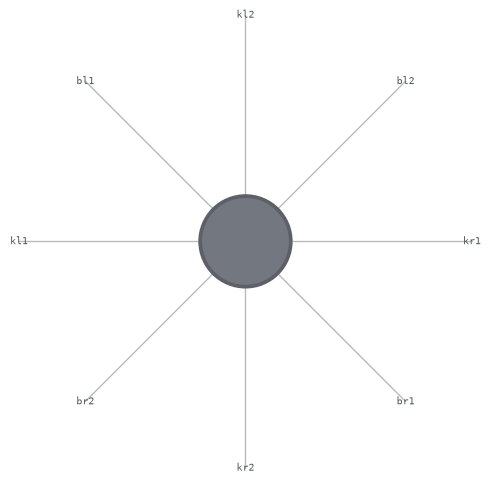

In [249]:
edm.draw()

In [250]:
fuse_map = {
    'kl': ['kl1', 'kl2'],
    'kr': ['kr1', 'kr2'],
    'bl': ['bl1', 'bl2'],
    'br': ['br1', 'br2']
}

In [251]:
edm = edm.fuse(fuse_map)

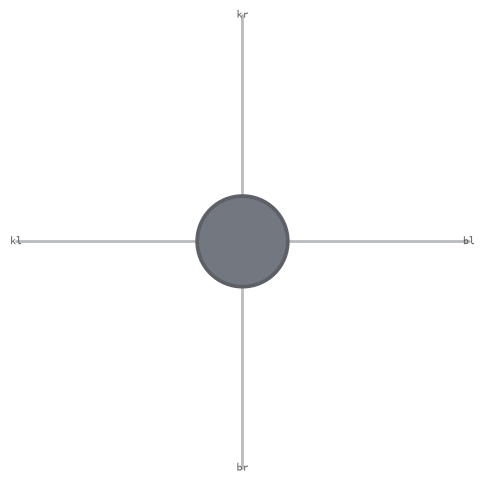

In [252]:
edm.draw()

In [253]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 11)),
    'left_defect_sites': [4, 5],
    'right_defect_sites': [9, 10]
}

In [254]:
np.sum(psi.conj()*psi)

np.complex128(0.9999999999999987+5.868301663317248e-20j)

In [255]:
X = np.zeros((2,)*8, dtype=complex)

for index in product(range(2), repeat=8):
    i1, i2, i3, i4, i5, i6, i7, i8 = index
    op1_pairs = spin_basis_ops[(i1, i2)]
    op2_pairs = fermion_basis_ops[(i3, i4)]
    op3_pairs = fermion_basis_ops[(i5, i6)]
    op4_pairs = spin_basis_ops[(i7, i8)]

    op = quantum_operator(
        {'_': [
            [f'{op1}{op4}|{op2}{op3}', [[s1*s2*s3*s4, 2,5 , 2,4]]]
            for op1, s1 in op1_pairs
            for op2, s2 in op2_pairs
            for op3, s3 in op3_pairs
            for op4, s4 in op4_pairs
        ]},
        basis=basis,
        check_herm=False
    )

    exp = op.expt_value(psi)

    X[*index] = exp.item()

/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_4353/3340808289.py:10: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  op = quantum_operator(
/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_4353/3340808289.py:10: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = quantum_operator(


In [256]:
rho = qtn.Tensor(data=X,
    inds=['k4', 'b4', 'k5', 'b5', 'k9', 'b9', 'k10', 'b10']
)

In [257]:
rho.reindex({'k4': 'b4', 'k5': 'b5', 'k9': 'b9', 'k10': 'b10'}).contract()

np.complex128(0.9999999999999998+5.868301663317238e-20j)

In [258]:
defect_opt_out = get_defect_ops_and_indices_from_edm(
    rho,
    edm,
    domains_dict
)

In [259]:
defect_opt_out[0]

array([0.25])

In [260]:
np.round(defect_opt_out[1].data, 3)

array([[ 0.   +0.j   , -0.   +0.j   ,  0.   +0.j   ,  0.995+0.104j],
       [ 0.   -0.j   ,  0.   -0.j   ,  0.995+0.104j, -0.   +0.j   ],
       [-0.   +0.j   ,  0.995+0.104j, -0.   -0.j   ,  0.   +0.j   ],
       [ 0.995+0.104j, -0.   +0.j   , -0.   -0.j   ,  0.   +0.j   ]])

In [261]:
X = defect_opt_out[1].data

In [262]:
np.round(X.conj() @ X, 3)

array([[ 1.+0.j,  0.+0.j, -0.-0.j,  0.+0.j],
       [-0.+0.j,  1.-0.j,  0.+0.j,  0.+0.j],
       [ 0.-0.j,  0.-0.j,  1.+0.j, -0.-0.j],
       [ 0.-0.j, -0.+0.j,  0.-0.j,  1.-0.j]])

In [263]:
X = defect_opt_out[2].data

In [264]:
np.round(X.conj() @ X, 3)

array([[-1.-0.j,  0.-0.j,  0.+0.j, -0.-0.j],
       [-0.-0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [-0.+0.j, -0.+0.j, -1.-0.j, -0.+0.j],
       [ 0.-0.j, -0.+0.j,  0.+0.j, -1.+0.j]])

In [265]:
np.round(defect_opt_out[2].data, 3)

array([[ 0.   -0.j   , -0.   +0.j   ,  0.   +0.j   , -0.995+0.104j],
       [-0.   +0.j   ,  0.   +0.j   , -0.995+0.104j, -0.   +0.j   ],
       [ 0.   +0.j   ,  0.995-0.104j, -0.   -0.j   , -0.   -0.j   ],
       [ 0.995-0.104j, -0.   +0.j   , -0.   -0.j   ,  0.   +0.j   ]])

Ok, something interesting happening.

In [266]:
defect_opt_out[3], defect_opt_out[4]

(np.complex128(-0.9999999999999998+0j), np.complex128(-0.9999999999999998+0j))

In [267]:
defect_opt_out[5], defect_opt_out[6]

(np.complex128(0.9999999999999998+0j), np.complex128(-0.9999999999999998+0j))

In [238]:
defect_opt_out[-1]

np.float64(0.9999999999999998)

In [239]:
exp

array([0.0625-8.94074817e-21j])

In [123]:
rho = (
    qt_psi
    & qt_psi.conj().reindex({'k5': 'b5', 'k9': 'b9'})
).contract()

In [124]:
np.round(rho.data, 3)

array([[[[ 0.25+0.j, -0.  -0.j],
         [-0.  +0.j,  0.  +0.j]],

        [[-0.  +0.j,  0.25+0.j],
         [-0.  -0.j,  0.  -0.j]]],


       [[[-0.  -0.j, -0.  +0.j],
         [ 0.25+0.j, -0.  -0.j]],

        [[ 0.  -0.j,  0.  +0.j],
         [-0.  +0.j,  0.25+0.j]]]])

In [125]:
def get_defect_ops_and_indices_from_edm(
    qt_rho, edm, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

In [126]:
defect_opt_out = get_defect_ops_and_indices_from_edm(
    rho, z_edm, domains_dict
)

In [127]:
defect_opt_out[0]

array([0.5])

In [130]:
np.round(defect_opt_out[1].data, 3)

array([[ 0.   +0.j   , -0.977-0.212j],
       [ 0.977+0.212j,  0.   +0.j   ]])

In [131]:
np.round(defect_opt_out[2].data, 3)

array([[ 0.   -0.j   ,  0.977-0.212j],
       [-0.977+0.212j, -0.   +0.j   ]])

In [132]:
defect_opt_out[3],defect_opt_out[4]

(np.complex128(-0.9999999999999387+0j),
 np.complex128(-0.9999999999999383+5.551115123125783e-17j))

In [133]:
defect_opt_out[5],defect_opt_out[6]

(np.complex128(-0.9999999999999387+0j),
 np.complex128(-0.9999999999999383-5.551115123125783e-17j))

In [135]:
defect_opt_out[8]

np.float64(1.0000000000000004)

Looks ok.